In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    brier_score_loss, recall_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_DIR = Path("/kaggle/input/datasets/test12345sdasd/email-triage-model-ready/")  # <-- update if needed

def load_jsonl(path):
    with open(path) as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

train = load_jsonl(DATA_DIR / "train.jsonl")
val   = load_jsonl(DATA_DIR / "val.jsonl")
test  = load_jsonl(DATA_DIR / "test.jsonl")

LABEL_MAP = {"spam": 0, "phishing": 1}
y_train = train["label"].map(LABEL_MAP).values
y_val   = val["label"].map(LABEL_MAP).values
y_test  = test["label"].map(LABEL_MAP).values

print(f"Train: {len(train)}  Val: {len(val)}  Test: {len(test)}")


Train: 15483  Val: 3188  Test: 3189


In [3]:

# ── CELL 3: Feature preparation ───────────────────────────────────────────────
# Zero-variance in this dataset — drop before fitting
DROP_COLS = ["executable_detected", "macro_detected"]

STRUCTURED_COLS = [
    "display_from_mismatch", "reply_to_mismatch", "free_email_sender",
    "url_count", "domain_count", "shortened_url_present", "suspicious_tld_present",
    "ip_literal_url", "url_entropy", "typosquatting_detected",
    "has_attachment",
    "subject_length", "body_length", "uppercase_ratio", "digit_ratio",
    "punctuation_density", "link_density",
    "brand_mention", "sender_brand_mismatch",
]

def get_text(df):
    subj = df["subject"].fillna("").astype(str)
    body = df["body_text"].fillna("").astype(str)
    return (subj + " [SEP] " + body).tolist()

# TF-IDF — LightGBM handles sparse input natively
tfidf = TfidfVectorizer(
    max_features=30_000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode",
)
X_text_train = tfidf.fit_transform(get_text(train))
X_text_val   = tfidf.transform(get_text(val))
X_text_test  = tfidf.transform(get_text(test))

# Structured features — LightGBM does NOT need scaling
X_struct_train = train[STRUCTURED_COLS].astype(float).values
X_struct_val   = val[STRUCTURED_COLS].astype(float).values
X_struct_test  = test[STRUCTURED_COLS].astype(float).values

from scipy.sparse import hstack, csr_matrix
X_train = hstack([X_text_train, csr_matrix(X_struct_train)])
X_val   = hstack([X_text_val,   csr_matrix(X_struct_val)])
X_test  = hstack([X_text_test,  csr_matrix(X_struct_test)])

feature_names = tfidf.get_feature_names_out().tolist() + STRUCTURED_COLS

print(f"Feature matrix — Train: {X_train.shape}")


Feature matrix — Train: (15483, 30019)


In [4]:

# ── CELL 4: Train LightGBM ────────────────────────────────────────────────────
lgb_train = lgb.Dataset(X_train, label=y_train, feature_name=feature_names)
lgb_val   = lgb.Dataset(X_val,   label=y_val,   reference=lgb_train)

params = {
    "objective":       "binary",
    "metric":          ["binary_logloss", "auc"],
    "learning_rate":   0.05,
    "num_leaves":      63,
    "min_child_samples": 20,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "lambda_l1":         0.1,
    "lambda_l2":         0.1,
    "verbose":          -1,
    "seed":             42,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=callbacks,
)

print(f"\nBest iteration: {model.best_iteration}")



Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0844988	valid_0's auc: 0.995811
[200]	valid_0's binary_logloss: 0.0695595	valid_0's auc: 0.996773
Early stopping, best iteration is:
[224]	valid_0's binary_logloss: 0.0691488	valid_0's auc: 0.996847

Best iteration: 224


In [7]:

# ── CELL 5: Calibrate on validation set ──────────────────────────────────────
# Use Platt scaling directly on raw LightGBM probabilities (no sklearn wrapper needed)
from scipy.special import expit
from scipy.optimize import minimize

raw_val_proba = model.predict(X_val)   # raw sigmoid outputs from LightGBM

# Fit Platt scaling: find a, b such that calibrated = sigmoid(a * raw + b)
def platt_loss(params, raw, y):
    a, b = params
    p = expit(a * raw + b)
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

result = minimize(platt_loss, x0=[1.0, 0.0], args=(raw_val_proba, y_val), method="L-BFGS-B")
platt_a, platt_b = result.x

def calibrated_predict_proba(X):
    raw = model.predict(X)
    p = expit(platt_a * raw + platt_b)
    return np.column_stack([1 - p, p])

# Unified interface matching the rest of the notebook
class CalibratedModel:
    def predict_proba(self, X):
        return calibrated_predict_proba(X)
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

calibrated = CalibratedModel()
print(f"Platt scaling fit: a={platt_a:.4f}, b={platt_b:.4f}")


Platt scaling fit: a=8.7819, b=-4.5789



  Validation Set
              precision    recall  f1-score   support

        spam     0.9769    0.9709    0.9739      1480
    phishing     0.9750    0.9801    0.9775      1708

    accuracy                         0.9758      3188
   macro avg     0.9759    0.9755    0.9757      3188
weighted avg     0.9759    0.9758    0.9758      3188

ROC-AUC:   0.9968
PR-AUC:    0.9971
Brier:     0.0205


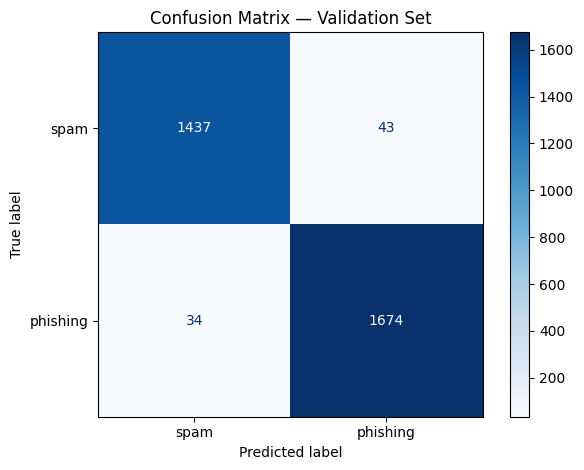


  Test Set (held-out)
              precision    recall  f1-score   support

        spam     0.9769    0.9716    0.9743      1481
    phishing     0.9755    0.9801    0.9778      1708

    accuracy                         0.9762      3189
   macro avg     0.9762    0.9759    0.9760      3189
weighted avg     0.9762    0.9762    0.9762      3189

ROC-AUC:   0.9959
PR-AUC:    0.9959
Brier:     0.0207


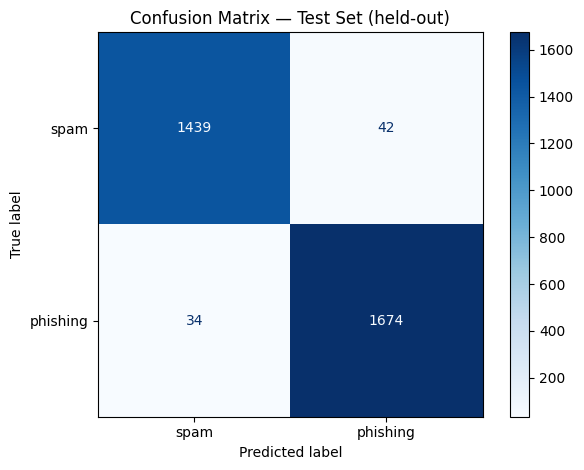

In [8]:

# ── CELL 6: Evaluate ──────────────────────────────────────────────────────────
def evaluate(model, X, y_true, split_name):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {split_name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["spam", "phishing"], digits=4))
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC:    {average_precision_score(y_true, y_proba):.4f}")
    print(f"Brier:     {brier_score_loss(y_true, y_proba):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["spam", "phishing"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {split_name}")
    plt.tight_layout(); plt.show()

    return y_proba

val_proba  = evaluate(calibrated, X_val,  y_val,  "Validation Set")
test_proba = evaluate(calibrated, X_test, y_test, "Test Set (held-out)")


In [9]:


# ── CELL 7: Confidence routing simulation ────────────────────────────────────
def trust_score(proba_phishing, w1=0.6, w2=0.4):
    max_prob = np.maximum(proba_phishing, 1 - proba_phishing)
    margin   = np.abs(2 * proba_phishing - 1)
    return (w1 * max_prob + w2 * margin) * 100

def route(trust):
    if trust > 90:  return "auto_classify"
    if trust > 75:  return "auto_classify_monitor"
    if trust > 55:  return "analyst_review"
    return "priority_analyst_review"

test_trust  = trust_score(test_proba)
test_routes = pd.Series([route(t) for t in test_trust])

print("\n=== ROUTING DISTRIBUTION (Test Set) ===")
print(test_routes.value_counts().to_dict())

auto_mask = test_trust > 75
print(f"\nAuto-classified: {auto_mask.sum()} / {len(y_test)} ({auto_mask.mean()*100:.1f}%)")
if auto_mask.sum() > 0:
    print(f"Phishing recall (auto only): {recall_score(y_test[auto_mask], (test_proba[auto_mask] >= 0.5).astype(int)):.4f}")

# Security override check: phishing_prob > 0.70 AND any high-risk signal
high_risk_signals = ["typosquatting_detected", "ip_literal_url", "reply_to_mismatch",
                     "suspicious_tld_present", "sender_brand_mismatch"]
test_high_risk = test[high_risk_signals].any(axis=1).values
override_mask  = (test_proba > 0.70) & test_high_risk
print(f"\nSecurity override triggered: {override_mask.sum()} emails")



=== ROUTING DISTRIBUTION (Test Set) ===
{'auto_classify': 3114, 'auto_classify_monitor': 37, 'analyst_review': 26, 'priority_analyst_review': 12}

Auto-classified: 3151 / 3189 (98.8%)
Phishing recall (auto only): 0.9829

Security override triggered: 614 emails


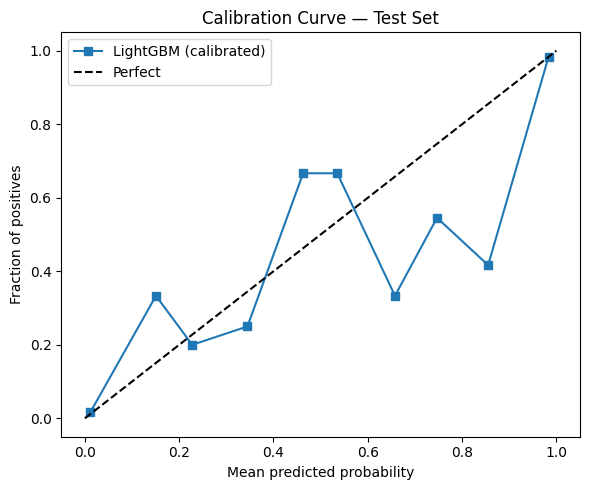

ECE: 0.4470  (target < 0.05)


In [10]:

# ── CELL 8: Calibration curve + ECE ──────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, "s-", label="LightGBM (calibrated)")
plt.plot([0, 1], [0, 1], "k--", label="Perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction of positives")
plt.title("Calibration Curve — Test Set"); plt.legend()
plt.tight_layout(); plt.show()

bin_edges = np.linspace(0, 1, 11)
ece = sum(
    ((test_proba >= bin_edges[i]) & (test_proba < bin_edges[i+1])).mean() *
    abs(
        (y_test[(test_proba >= bin_edges[i]) & (test_proba < bin_edges[i+1])] ==
         (test_proba[(test_proba >= bin_edges[i]) & (test_proba < bin_edges[i+1])] >= 0.5).astype(int)).mean()
        - test_proba[(test_proba >= bin_edges[i]) & (test_proba < bin_edges[i+1])].mean()
    )
    for i in range(len(bin_edges) - 1)
    if ((test_proba >= bin_edges[i]) & (test_proba < bin_edges[i+1])).sum() > 0
)
print(f"ECE: {ece:.4f}  (target < 0.05)")





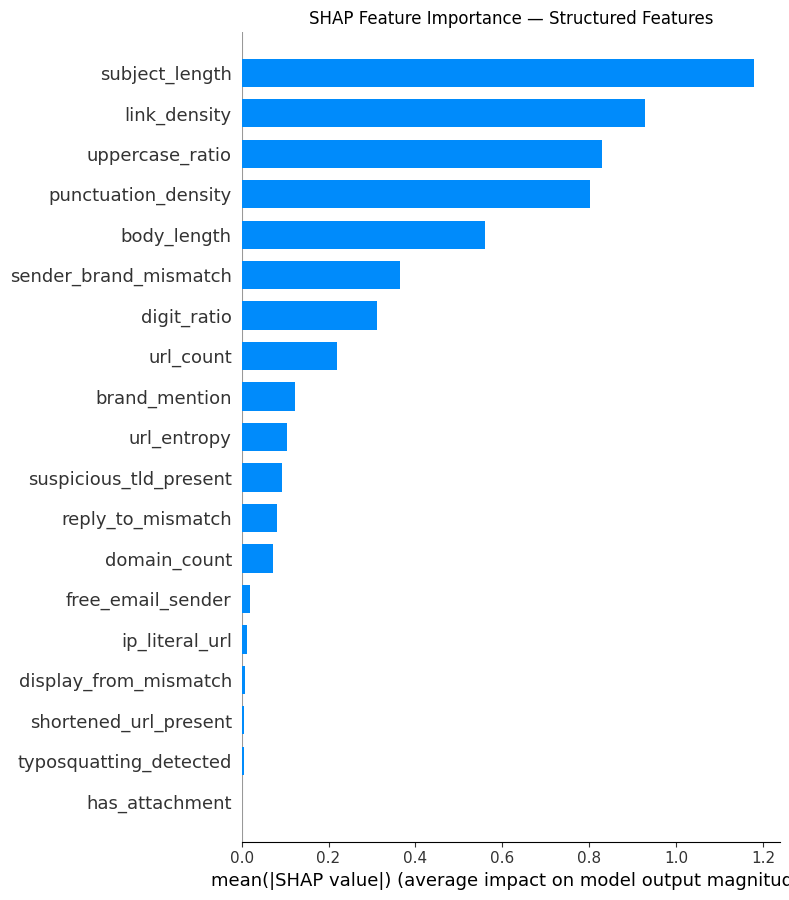

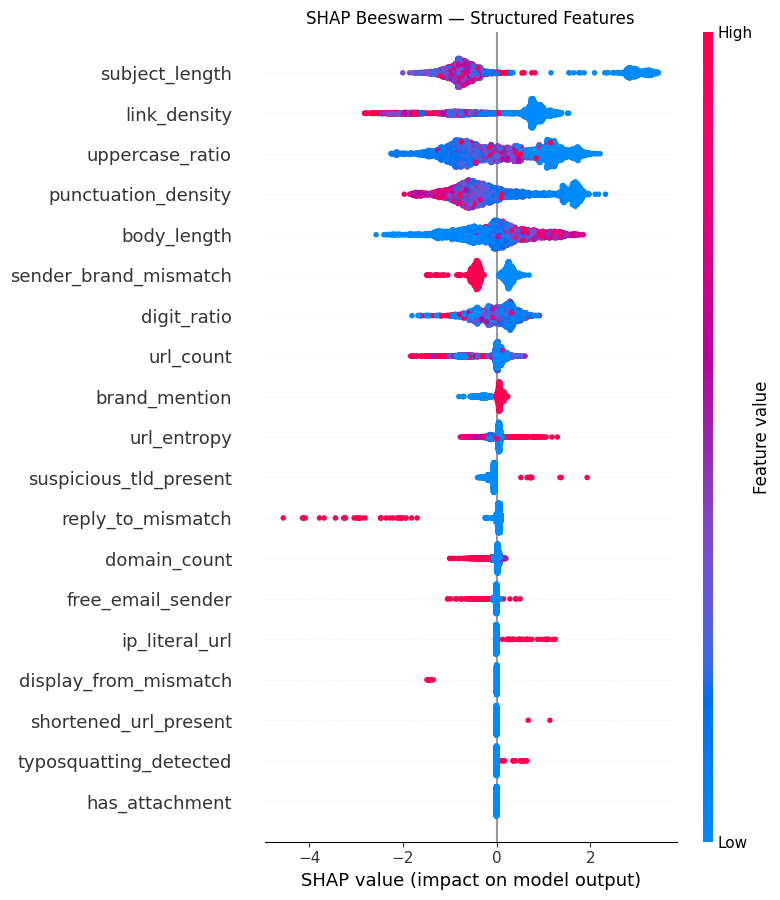

In [11]:

# ── CELL 9: SHAP explainability (structured features only) ───────────────────
# SHAP on full sparse matrix is slow — explain structured features only
X_struct_test_df = pd.DataFrame(X_struct_test, columns=STRUCTURED_COLS)

# Re-train a structured-only LightGBM for SHAP (fast, interpretable)
lgb_struct_train = lgb.Dataset(X_struct_train, label=y_train)
lgb_struct_val   = lgb.Dataset(X_struct_val,   label=y_val, reference=lgb_struct_train)

struct_model = lgb.train(
    {**params, "num_leaves": 31},
    lgb_struct_train,
    num_boost_round=300,
    valid_sets=[lgb_struct_val],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

explainer   = shap.TreeExplainer(struct_model)
shap_values = explainer.shap_values(X_struct_test)

plt.figure()
shap.summary_plot(shap_values, X_struct_test_df, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Structured Features")
plt.tight_layout(); plt.show()

plt.figure()
shap.summary_plot(shap_values, X_struct_test_df, show=False)
plt.title("SHAP Beeswarm — Structured Features")
plt.tight_layout(); plt.show()


In [12]:

# ── CELL 10: Save model artifacts ────────────────────────────────────────────
import pickle, os

OUT_DIR = Path("/kaggle/working")
model.save_model(str(OUT_DIR / "lgbm_phase2.txt"))

with open(OUT_DIR / "tfidf_phase2.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open(OUT_DIR / "calibrated_phase2.pkl", "wb") as f:
    pickle.dump(calibrated, f)

print("Artifacts saved to /kaggle/working/")

Artifacts saved to /kaggle/working/


---

## Phase 2B

In [19]:
from scipy.special import expit, logit
from scipy.optimize import minimize_scalar
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

raw_val_proba = model.predict(X_val)
raw_test_proba = model.predict(X_test)

def temperature_loss(T, raw, y):
    p = expit(logit(np.clip(raw, 1e-7, 1-1e-7)) / T)
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

result = minimize_scalar(temperature_loss, bounds=(0.1, 10.0), method="bounded",
                         args=(raw_val_proba, y_val))
T_opt = result.x

def temp_scale(raw, T):
    return expit(logit(np.clip(raw, 1e-7, 1-1e-7)) / T)

test_proba_temp = temp_scale(raw_test_proba, T_opt)
val_proba_temp  = temp_scale(raw_val_proba,  T_opt)

print(f"Optimal temperature T = {T_opt:.4f}")
print(f"Brier (Platt):       {brier_score_loss(y_test, test_proba):.4f}")
print(f"Brier (Temperature): {brier_score_loss(y_test, test_proba_temp):.4f}")


Optimal temperature T = 1.1394
Brier (Platt):       0.0207
Brier (Temperature): 0.0191


In [15]:

# ── CELL 4: Precision-Recall curve comparison ─────────────────────────────────
def plot_pr_curves(y_true, probas_dict):
    plt.figure(figsize=(7, 5))
    for name, proba in probas_dict.items():
        prec, rec, _ = precision_recall_curve(y_true, proba)
        from sklearn.metrics import average_precision_score
        ap = average_precision_score(y_true, proba)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.4f})")
    plt.xlabel("Recall (Phishing)")
    plt.ylabel("Precision (Phishing)")
    plt.title("Precision-Recall Curve — Phishing Class")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

ECE (Platt scaling):       0.4470
ECE (Temperature scaling): 0.4455
Target:                    < 0.05


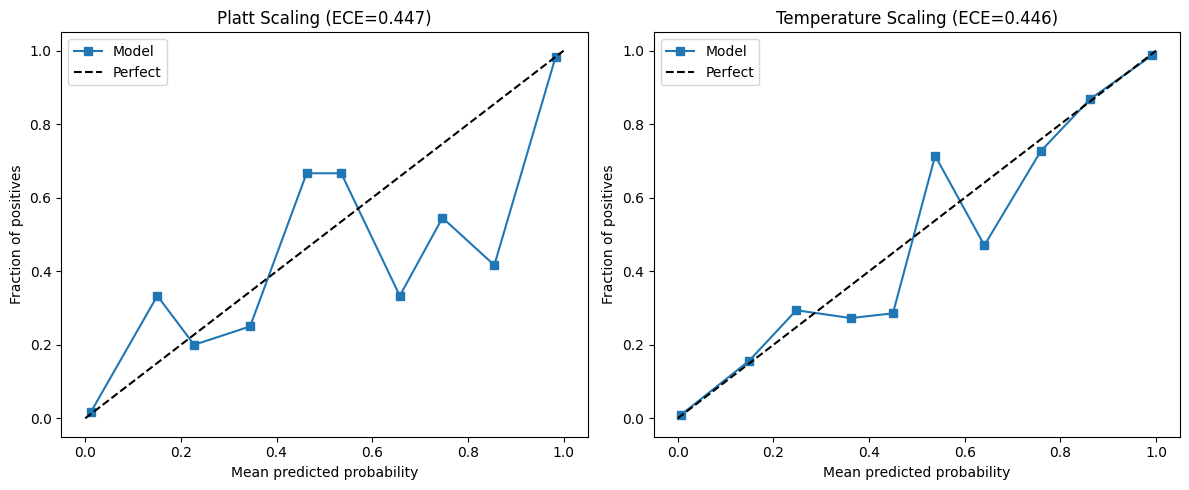


Using Temperature scaling for remaining analysis.


In [20]:

# ── CELL 12: ECE comparison — Platt vs Temperature ───────────────────────────
def compute_ece(y_true, proba, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (proba >= bin_edges[i]) & (proba < bin_edges[i+1])
        if mask.sum() == 0:
            continue
        acc  = (y_true[mask] == (proba[mask] >= 0.5).astype(int)).mean()
        conf = proba[mask].mean()
        ece += mask.mean() * abs(acc - conf)
    return ece

ece_platt = compute_ece(y_test, test_proba)
ece_temp  = compute_ece(y_test, test_proba_temp)

print(f"ECE (Platt scaling):       {ece_platt:.4f}")
print(f"ECE (Temperature scaling): {ece_temp:.4f}")
print(f"Target:                    < 0.05")

# Calibration curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, proba, title in [
    (axes[0], test_proba,      f"Platt Scaling (ECE={ece_platt:.3f})"),
    (axes[1], test_proba_temp, f"Temperature Scaling (ECE={ece_temp:.3f})"),
]:
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(prob_pred, prob_true, "s-", label="Model")
    ax.plot([0, 1], [0, 1], "k--", label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

# Use whichever calibration is better going forward
best_proba = test_proba_temp if ece_temp < ece_platt else test_proba
best_label = "Temperature" if ece_temp < ece_platt else "Platt"
print(f"\nUsing {best_label} scaling for remaining analysis.")



In [21]:

# ── CELL 13: Threshold sweep ──────────────────────────────────────────────────
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)
rows = []
for t in thresholds:
    pred = (best_proba >= t).astype(int)
    rows.append({
        "threshold":       round(t, 2),
        "phishing_recall": round(recall_score(y_test, pred, pos_label=1, zero_division=0), 4),
        "spam_precision":  round(precision_score(y_test, pred, pos_label=0, zero_division=0), 4),
        "f1_phishing":     round(f1_score(y_test, pred, pos_label=1, zero_division=0), 4),
    })

df_sweep = pd.DataFrame(rows)
print("=== THRESHOLD SWEEP — LightGBM (Test Set) ===")
print(df_sweep.to_string(index=False))



=== THRESHOLD SWEEP — LightGBM (Test Set) ===
 threshold  phishing_recall  spam_precision  f1_phishing
      0.05           0.9953          0.9941       0.9599
      0.10           0.9918          0.9899       0.9669
      0.15           0.9906          0.9887       0.9705
      0.20           0.9889          0.9867       0.9729
      0.25           0.9871          0.9847       0.9740
      0.30           0.9859          0.9834       0.9748
      0.35           0.9848          0.9821       0.9756
      0.40           0.9824          0.9795       0.9776
      0.45           0.9813          0.9782       0.9775
      0.50           0.9813          0.9782       0.9784
      0.55           0.9789          0.9756       0.9775
      0.60           0.9783          0.9750       0.9775
      0.65           0.9748          0.9711       0.9771
      0.70           0.9737          0.9699       0.9777
      0.75           0.9719          0.9680       0.9779
      0.80           0.9643          0.959


=== ROUTING BAND ANALYSIS — LightGBM (Temperature calibration) ===
Band                          Count  %Total  Ph.Recall  FN Rate
-----------------------------------------------------------------
auto_classify                  2970   93.1%     0.9919   0.0081
auto_classify_monitor           117    3.7%     0.9231   0.0769
analyst_review                   53    1.7%     0.7500   0.2500
priority_review                  49    1.5%     0.6316   0.3684


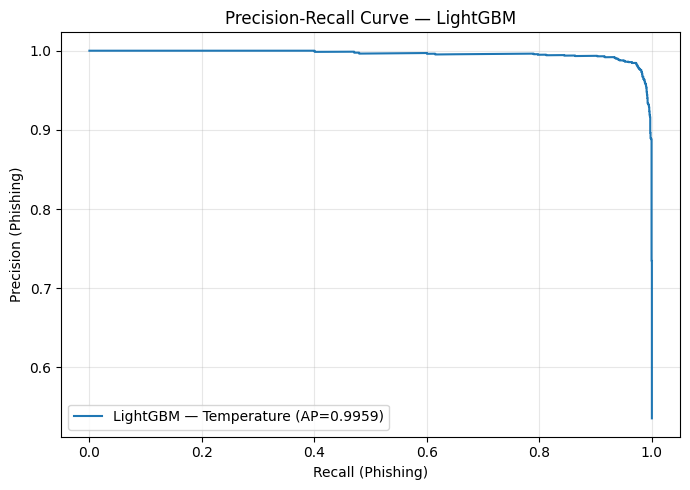

In [22]:

# ── CELL 14: Routing band analysis ───────────────────────────────────────────
def trust_score(p, w1=0.6, w2=0.4):
    return (w1 * np.maximum(p, 1-p) + w2 * np.abs(2*p - 1)) * 100

scores = trust_score(best_proba)
bands = [
    ("auto_classify",         scores > 90),
    ("auto_classify_monitor", (scores > 75) & (scores <= 90)),
    ("analyst_review",        (scores > 55) & (scores <= 75)),
    ("priority_review",       scores <= 55),
]

print(f"\n=== ROUTING BAND ANALYSIS — LightGBM ({best_label} calibration) ===")
print(f"{'Band':<28} {'Count':>6} {'%Total':>7} {'Ph.Recall':>10} {'FN Rate':>8}")
print("-" * 65)

total = len(y_test)
for band_name, mask in bands:
    if mask.sum() == 0:
        continue
    band_true = y_test[mask]
    band_pred = (best_proba[mask] >= 0.5).astype(int)
    ph_in_band = (band_true == 1).sum()
    fn_in_band = ((band_true == 1) & (band_pred == 0)).sum()
    ph_recall  = recall_score(band_true, band_pred, pos_label=1, zero_division=0) if ph_in_band > 0 else float("nan")
    fn_rate    = fn_in_band / ph_in_band if ph_in_band > 0 else 0.0
    print(f"{band_name:<28} {mask.sum():>6} {mask.sum()/total*100:>6.1f}%  {ph_recall:>9.4f}  {fn_rate:>7.4f}")


# ── CELL 15: PR curve ─────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, best_proba)
ap = average_precision_score(y_test, best_proba)

plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label=f"LightGBM — {best_label} (AP={ap:.4f})")
plt.xlabel("Recall (Phishing)")
plt.ylabel("Precision (Phishing)")
plt.title("Precision-Recall Curve — LightGBM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:

# ── CELL 16: Final summary ────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, roc_auc_score

pred_final = (best_proba >= 0.5).astype(int)
print("=== PHASE 2 FINAL SUMMARY (with best calibration) ===")
print(f"Calibration method:  {best_label} scaling")
print(f"ECE:                 {min(ece_platt, ece_temp):.4f}  (target < 0.05)")
print(f"Accuracy:            {accuracy_score(y_test, pred_final):.4f}")
print(f"Phishing Recall:     {recall_score(y_test, pred_final, pos_label=1):.4f}  (target > 0.98)")
print(f"Phishing Precision:  {precision_score(y_test, pred_final, pos_label=1):.4f}")
print(f"ROC-AUC:             {roc_auc_score(y_test, best_proba):.4f}")
print(f"Brier Score:         {brier_score_loss(y_test, best_proba):.4f}")
auto_mask = trust_score(best_proba) > 75
print(f"Auto-classify rate:  {auto_mask.mean()*100:.1f}%")
print(f"Ph. recall (auto):   {recall_score(y_test[auto_mask], pred_final[auto_mask], pos_label=1):.4f}")


=== PHASE 2 FINAL SUMMARY (with best calibration) ===
Calibration method:  Temperature scaling
ECE:                 0.4455  (target < 0.05)
Accuracy:            0.9768
Phishing Recall:     0.9813  (target > 0.98)
Phishing Precision:  0.9756
ROC-AUC:             0.9959
Brier Score:         0.0191
Auto-classify rate:  96.8%
Ph. recall (auto):   0.9892
